# Training algorithm for O2 gapfill
    - Updated for full depth, coverage up to 2025
    - Needs to enter a 6 digit input parameter as follows : 
    - First digit = Algorithm type (1=RF, 2=NN)
    - Second digit = Data Source (1=Ship only, 2=Ship+Argo)
    - Third digit = Ocean basin (1=Atlantic, 2=Pacific, 3=Indian, 4=Southern, 5=Arctic)
    - Fourth digit = T/S data source (1=EN4, 2=ORAS4, 3=SODA3.4.2, 4=EN4/C14)
    - Fifth digit = predictor variable set (1=[T,S,p,lon,lat,year,month], 2=[T,S,p,lon,lat,year,cos/sin_month], 3=[T,S,p,lon,lat,year,cos/sin_month,sigma-theta], 4=[T,S,p,lon,lat,year,cos/sin_month,sigma-theta,N2], 5=[T,S,p,lon,lat,cos/sin_month], 6=[T,S,p,lon,lat,GlobalSST,cos/sin_month])
    - Sixth digit = hyperparameter set (1=default, 2=preset hyperparameters, 4=DKCV)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import sklearn as skl
import gsw
import cartopy.crs as ccrs
from scipy.interpolate import interp1d
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
# version information
ver = '1.7.1.5.6.4'
# The version information will determine which basin / algorithm will be used to calculate the O2 maps. 
o2_cutoff = 600 # this is an arbitrary defined cut-off value to remove very large O2 input data from Argo
#
os.system('echo $USER > userid')
usrid=np.genfromtxt('userid',dtype='<U16')
scratch=f'/storage/home/hcoda1/8/{usrid}/scratch'
data_root='/storage/project/r-takamitsu3-0/shared/ugit0034'
#
# combine OSD, CTD and PFL equally
eqave=0
# eqave=0 means the o2 value is weighted by profile count
argo_offset = 1.69
#
# hyperbolic tangent correction function
tanhcorr = 1
Ztr   = 150.
Zwidth= 30.
#
max_zdep = 2000.

### display selection

In [3]:
selection = ver.split('.')
basin = ['Atlantic','Pacific','Indian','Southern','Arctic']
#
if selection[0] == '1':
    print('Random Forst algorithm will be used.')
    alg = 'RF'
elif selection[0] == '2':
    print('Neural Network algorithm will be used.')
    alg = 'NN'
else:
    print('error - incorrect algorithm type')
#
if selection[1] == '1':
    print('Ship-based O2 data will be used. ')
    Omod='S'
elif selection[1] == '2':
    print('Ship-based and Argo-O2 data will be used. ')
    Omod='SA'
elif (selection[1] == '3') | (selection[1] == '4'):
    print('Ship-based and modified Argo-O2 data will be used. ')
    if tanhcorr == 1:
        Omod='ScA_tanh'
    else:
        Omod='ScA'
elif selection[1]=='5':
    print('w25 input data is used. ')
    Omod = 'w25'
elif selection[1]=='6':
    print('IAP v.2026 input data is used. ')
    Omod = 'IAP26'
elif selection[1]=='7':
    print('NCEI v.2026 input data is used. ')
    Omod = 'NCEI26'
else:
    print('error - incorrect input data type')
#
if selection[2] == '1':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '2':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '3':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '4':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '5':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
else:
    print('error - incorrect O2 data type')
#
if selection[3] == '1':
    print('EN4 dataset will be used for T/S input. ')
    TSref='EN4L09'
elif selection[3] == '2':
    print('ORAS4 dataset will be used for T/S input. ')
    TSref='ORAS4'
elif selection[3] == '3':
    print('SODA3.4.2 dataset will be used for T/S input. ')
    TSref='SODA342'
elif selection[3] == '4':
    print('EN4 (C14) dataset will be used for T/S input. ')
    TSref='EN4C14'
elif selection[3] == '5':
    print('IAP dataset will be used for T/S input. ')
    TSref='IAP'
else:
    print('error - incorrect T/S data type')
#
if selection[4] == '1':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, month')
elif selection[4] == '2':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)')
elif selection[4] == '3':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma0')
elif selection[4] == '4':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma0, N2')
#NEW
elif selection[4] == '5':
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '6':
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
#NEW
else:
    print('error - incorrect predictor variable type')
#
if selection[5] == '1':
    print('Hyperparameter set is optimized via K-fold CV')
elif selection[5] == '2':
    print('A pre-set hyperparameter set is used')
elif selection[5] == '4':
    print('New train/test splid and K-fold cross validation')
else:
    print('error - incorrect hyperparameter type')
#
#
dirn=f'{scratch}/ML4O2/input_{TSref}_{Omod}'
com=f'mkdir -p {dirn}'
print(dirn)
os.system(com)
#


Random Forst algorithm will be used.
NCEI v.2026 input data is used. 
Atlantic Ocean will be mapped
IAP dataset will be used for T/S input. 
Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)
New train/test splid and K-fold cross validation
/storage/home/hcoda1/8/takamitsu3/scratch/ML4O2/input_IAP_NCEI26


0

In [4]:
# Define the input and output folders
#
os.system('echo $USER > userid')
usrid=np.genfromtxt('userid',dtype='<U8')
os.system('rm userid')
diro = f'{scratch}/ML4O2_temp/'
if selection[3]=='1':
    dirf = f'{data_root}/EN4/L09_20x180x360/'
    dbase='EN4_TSN2_L09_180x360_'
    roll180=0
elif selection[3]=='2':
    dirf = f'{data_root}/ORAS4/TSN2/'
    dbase='ORAS4_TSN2_'
    roll180=1
elif selection[3]=='4':
    dirf = f'{data_root}/EN4/C14/'
    dbase='EN4_C14_180x360_'
    roll180=0
elif selection[3]=='5':
    dirf = f'{data_root}/IAP/'
    dbase='IAP_180x360_'
    roll180=0
# This is where the source data is ---
dirin = f'{data_root}/WOD_O2_2022-25/'
#dirin = f'{data_root}/Zhankun/'
#
fosd='_1x1bin_osd_1965-2025'
fctd='_1x1bin_ctd_1987-2025'
fpfl='_1x1bin_pfl_2005-2025'
var=['Oxygen']
os.system('mkdir -p '+diro)
os.system('mkdir -p '+diro+'temp')

0

### Preprocessing the data
- New in 2025
- Depth is extended to max_depth (determined at the top)
- Training data is including Global mean SST rather than year

In [5]:
# obtain vertical grid
#
ds0 = xr.open_dataset(f'{dirf}{dbase}196501.nc')
Z = ds0.depth.sel(depth=slice(0,max_zdep)).to_numpy()
Nz=np.size(Z)
print(Nz,Z)

67 [   0.    5.   10.   15.   20.   25.   30.   35.   40.   45.   50.   55.
   60.   65.   70.   75.   80.   85.   90.   95.  100.  125.  150.  175.
  200.  225.  250.  275.  300.  325.  350.  375.  400.  425.  450.  475.
  500.  550.  600.  650.  700.  750.  800.  850.  900.  950. 1000. 1050.
 1100. 1150. 1200. 1250. 1300. 1350. 1400. 1450. 1500. 1550. 1600. 1650.
 1700. 1750. 1800. 1850. 1900. 1950. 2000.]


In [6]:
# select analysis period
endyear=2025
# do not change the start year from 1965 (this is when Carpenter 1965 established modern Winkler method)
yrs=np.arange(1965,endyear+1,1)
yrs

array([1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024, 2025])

Atlantic Ocean will be mapped


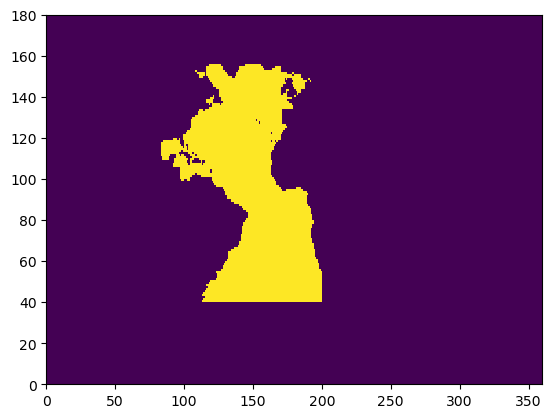

In [7]:
# basin mask
dsm=xr.open_dataset(f'{data_root}/WOD18/basin_mask_01.nc')
ma = dsm.basin_mask.isel(depth=0).to_numpy()
#
if selection[2] == '1':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==1,1,0)
elif selection[2] == '2':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==2,1,0)
elif selection[2] == '3':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where((ma==3)|(ma==56),1,0)
elif selection[2] == '4':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==10,1,0)
elif selection[2] == '5':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==11,1,0)
else:
    print('error - incorrect O2 data type')
#
plt.pcolormesh(mask)

In [8]:
if selection[1]=='5':
    # get yearly anomaly
    ds4=xr.open_dataset('../../Ito22_OI_mapping/w25_o_19652025_yearly_anomaly_NCEI.nc').roll(lon=180)
    # get monthly climatology
    ds4a=xr.open_dataset('../../Ito22_OI_mapping/DOMIP1_NCEI_19652022_LTM_annual_apr2025.nc').sel(maps='Ito')
    ds4m=xr.open_dataset('../../Ito22_OI_mapping/DOMIP1_NCEI_19652022_LTM_monthly_apr2025.nc').sel(maps='Ito')
    Nzt=57
    o2c=np.zeros((12,102,180,360)).astype('float32')
    for m in range(12):
        o2c[m,Nzt:,:,:]=ds4a.o2[Nzt:,:,:].roll(lon=180).to_numpy().astype('float32')
        o2c[m,:Nzt,:,:]=ds4m.o2[m,:,:,:].roll(lon=180).to_numpy().astype('float32')
elif selection[1]=='6':
    #lon0=ds0.lon.to_numpy()
    ds4=xr.open_dataset('~/shared/ugit0034/IAP/IAP_202608/Oxygen_IAP_1x1bin_1965-2025_lon-180to180.nc')
    #ds4=xr.open_dataset('~/shared/ugit0034/IAP/IAP_202608/Oxygen_IAP_1x1bin_1965-2025.nc').roll(lon=180).assign_coords(lon=lon0).astype('float32')
elif selection[1]=='7':
    #lon0=ds0.lon.to_numpy()
    ds4=xr.open_dataset('~/shared/ugit0034/Zhankun/202608/Oxygen_NCEI_1x1bin_1965-2025.nc')

In [9]:
#plt.pcolormesh(o2c[0,0,:,:])
ds4
#o2=ds4.Oxygen.astype('float32')
#lon0

<xarray.Dataset> Size: 34GB
Dimensions:           (time: 732, depth: 102, lat: 180, lon: 360)
Coordinates:
  * time              (time) datetime64[ns] 6kB 1965-01-01 ... 2025-12-01
  * depth             (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * lat               (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon               (lon) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    o2                (time, depth, lat, lon) float32 19GB ...
    sample_count_OSD  (time, depth, lat, lon) int8 5GB ...
    sample_count_CTD  (time, depth, lat, lon) int8 5GB ...
    sample_count_PFL  (time, depth, lat, lon) int8 5GB ...

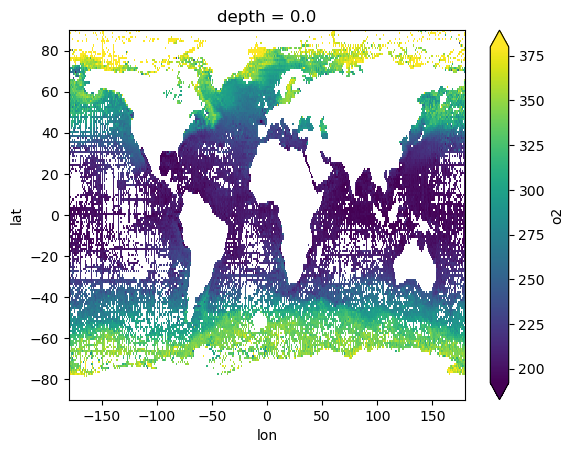

In [10]:
if selection[1]=='6':
    ds4.Oxygen[:,0,:,:].mean('time').plot(robust=True)
elif selection[1]=='7':
    ds4.o2[:,0,:,:].mean('time').plot(robust=True)
#ds4.to_netcdf('~/shared/ugit0034/IAP/IAP_202608/Oxygen_IAP_1x1bin_1965-2025_lon-180to180.nc')

In [11]:
if selection[1]=='6':
    o2=ds4.Oxygen.sel(depth=slice(0,max_zdep)).to_numpy().astype('float32')
elif selection[1]=='7':
    o2=ds4.o2.sel(depth=slice(0,max_zdep)).to_numpy().astype('float32')
else:
    # NEW in 2025
    # Obtain O2 data from observational dataset
    #
    #  Argo O2 bias correction can happen here!
    #
    Nyr=np.size(yrs)
    Nt=Nyr*12
    mon=["%.2d" % i for i in np.arange(1,13,1)]
    #
    # float32, not float64: this is the single biggest array in the notebook
    # (Nt x Nz x 180 x 360) and the raw Oxygen values are float64 on disk, so
    # without an explicit dtype here this array alone is ~19GB instead of ~9.5GB.
    # Assignments below (o2[...] = ...) downcast the float64 source data
    # automatically since the destination array is float32.
    o2=np.zeros((Nt,Nz,180,360),dtype=np.float32)
    #
    ds1=xr.open_dataset(dirin+var[0]+fosd+'.nc')
    ds2=xr.open_dataset(dirin+var[0]+fctd+'.nc')
    ds3=xr.open_dataset(dirin+var[0]+fpfl+'.nc')
    #
    if tanhcorr == 1:
        # prepare tanh correction function
        Nt0,Nz0,Ny0,Nx0 = ds1.Oxygen.shape
        f=np.zeros((1,Nz0,1,1))
        f[0,:,0,0] = argo_offset*( np.tanh((ds1.depth-Ztr)/Zwidth) + 1 )/2
        tanh_offset = np.tile(f,[12,1,180,360]).astype('float32')
    #    
    for year in yrs:
        ytmp=year%10
        if ytmp==0:
            print(str(year))
        tr=12*(year-1965)
        timeind0=(year-2005)*12
        if selection[1]=='5':
            oanom=ds4.o_anom_mn.isel(time=year-1965).to_numpy().astype('float32')
            o2[tr:(tr+12),:67,:,:]=o2c[:,:67,:,:]+oanom[np.newaxis,:,:,:]
            o2[tr:(tr+12),67:,:,:]=o2c[:,67:,:,:]
        elif (year<1987):#|(selection[1]=='1'):
            o2[tr:(tr+12),:,:,:]=ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        elif (year<2005)|(selection[1]=='1'):
            o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            o2b=np.where(np.isnan(o2b),0,o2b)
            o2c=np.where(np.isnan(o2c),0,o2c)
            if eqave == 1:
                cntb[cntb>1]=1 # equal weights
                cntc[cntc>1]=1
            o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc)/(cntb+cntc)
        elif (selection[1]=='2'):
            o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            o2p = ds3.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            cntp= ds3.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            o2b=np.where(np.isnan(o2b),0,o2b)
            o2c=np.where(np.isnan(o2c),0,o2c)
            o2p=np.where(np.isnan(o2p),0,o2p)
            if eqave == 1:
                cntb[cntb>1]=1 # equal weights
                cntc[cntc>1]=1
                cntp[cntp>1]=1
            o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc+o2p*cntp)/(cntb+cntc+cntp)
        elif (selection[1]=='3'):
            o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            o2p = ds3.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            cntp= ds3.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
            #
            argo_bad = o2p > o2_cutoff
            if tanhcorr == 1:
                o2p = np.where(argo_bad, np.nan, o2p) + tanh_offset
            else:
                o2p = np.where(argo_bad, np.nan, o2p) + argo_offset
            #
            o2b=np.where(np.isnan(o2b),0,o2b)
            o2c=np.where(np.isnan(o2c),0,o2c)
            o2p=np.where(np.isnan(o2p),0,o2p)
            #
            if eqave == 1:
                cntb[cntb>1]=1 # equal weights
                cntc[cntc>1]=1
                cntp[cntp>1]=1
            o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc+o2p*cntp)/(cntb+cntc+cntp)
        # result quick check
        #tmp=o2[tr:(tr+12),:,:,:].flatten()
        #print(year,np.nanmax(tmp),np.nanmin(tmp))

732 67


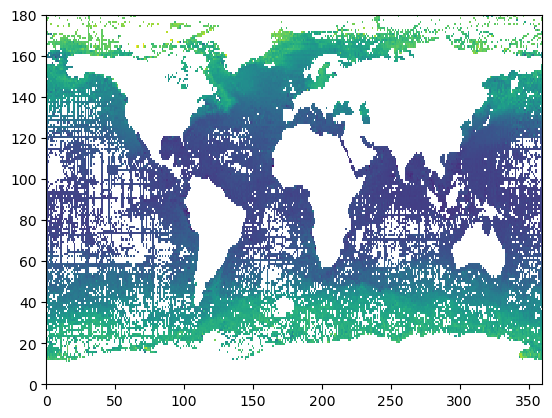

In [12]:
plt.pcolormesh(np.nanmean(o2[:,0,:,:],axis=0))
Nt=ds4.dims['time']
print(Nt,Nz)
mon=["%.2d" % i for i in np.arange(1,13,1)]

In [13]:
#
# Obtain T/S data from observational gridded dataset
#
# np.full(..., dtype=np.float32) instead of np.zeros(...)*np.nan: the old
# form is float64 regardless of what's assigned into it (Nt x Nz x 180 x 360
# each -- ~19GB per array, ~38GB for t+s combined -- this is what was
# crashing the kernel). so/thetao are already float32 on disk, so this loses
# no precision that wasn't already float32 upstream.
t=np.full((Nt,Nz,180,360),np.nan,dtype=np.float32)
s=np.full((Nt,Nz,180,360),np.nan,dtype=np.float32)
#
for year in yrs:
    ytmp=year%10
    if ytmp==0:
        print(str(year))
    tr=12*(year-1965)
    if year <= 2024:
        Nmon=12
    else:
        Nmon=12
    for mn in range(Nmon):
        ds = xr.open_dataset(dirf+dbase+str(year)+mon[mn]+'.nc')
        print(dirf+dbase+str(year)+mon[mn]+'.nc')
        if roll180==1:
            ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
            ds = ds.sortby(ds.lon)
        tmps=ds.so.interp(depth=Z).to_numpy().squeeze()
        tmps=np.where(tmps>100,np.nan,tmps)
        s[tr+mn,:,:,:]=tmps.astype('float32')
        t[tr+mn,:,:,:]=ds.thetao.interp(depth=Z).to_numpy().astype('float32').squeeze()

/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196501.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196502.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196503.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196504.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196505.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196506.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196507.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196508.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196509.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196510.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196511.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196512.nc
/storage/project/r-takamitsu3-0/shared/ugit0034/IAP/IAP_180x360_196601.nc
/storage/project/r-takamitsu3-0/shared

In [14]:
# get coordinates
x=ds.lon.to_numpy().astype(np.float32)
# use alternative x coordinate: longitude - 20
xa0 = x - 20
xalt = np.where(xa0<0,xa0+360,xa0)
#
y=ds.lat.to_numpy().astype(np.float32)
xi=np.arange(0,360,1)
yi=np.arange(0,180,1)
xx,yy=np.meshgrid(xalt,y)
xxi,yyi=np.meshgrid(xi,yi)

In [15]:
# extract mask
mask2d=np.zeros((1,180,360),dtype=np.float32)
mask2d[0,:,:] = dsm.basin_mask.sel(depth=0)
mask2d = np.where(mask2d==56,3,mask2d)
mask3d = np.tile(mask2d,[np.size(Z),1,1])
mask= dsm.basin_mask.sel(depth=Z)
#
mask=np.where(mask==0,0,mask3d)
#print(np.shape(mask))
#np.unique(mask2d)

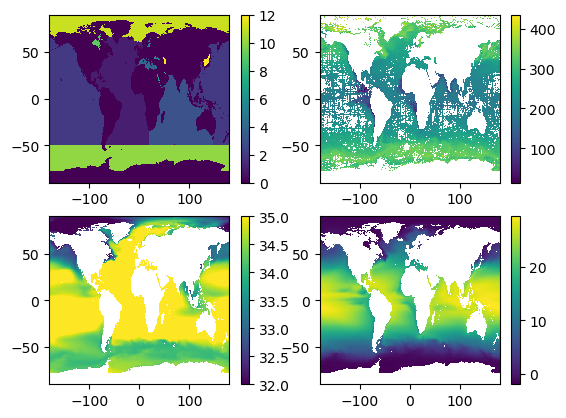

In [16]:
# take a look at the data
fig,ax=plt.subplots(2,2)
# select 500m for plotting
kind=[idx for idx,elem in enumerate(Z) if elem==50]
#
im=ax[0,0].pcolormesh(x,y,mask[8,:,:],vmin=0,vmax=12,label='basin_mask')
plt.colorbar(im,ax=ax[0,0])
im=ax[0,1].pcolormesh(x,y,np.nanmean(o2[:,kind[0],:,:],axis=0))
plt.colorbar(im,ax=ax[0,1])
im=ax[1,0].pcolormesh(x,y,np.nanmean(s[:,kind[0],:,:],axis=0),vmin=32,vmax=35)
plt.colorbar(im,ax=ax[1,0])
im=ax[1,1].pcolormesh(x,y,np.nanmean(t[:,kind[0],:,:],axis=0))
plt.colorbar(im,ax=ax[1,1])

In [17]:
print(dirn)
print(Nz)

/storage/home/hcoda1/8/takamitsu3/scratch/ML4O2/input_IAP_NCEI26
67


In [18]:
# prepare depth lat lon time data
xx1  = np.tile(xx,[Nz,1,1])
yy1  = np.tile(yy,[Nz,1,1])
xxSO = (yy+90)*np.cos(np.deg2rad(xx))
yySO = (yy+90)*np.sin(np.deg2rad(xx))
xxAO = (-yy+90)*np.cos(np.deg2rad(xx))
yyAO = (-yy+90)*np.sin(np.deg2rad(xx))
#
xx1SO = np.tile(xxSO,[Nz,1,1])
yy1SO = np.tile(yySO,[Nz,1,1])
xx1AO = np.tile(xxAO,[Nz,1,1])
yy1AO = np.tile(yyAO,[Nz,1,1])
ztmp  = np.tile(Z,[180,360,1])
zz1   = np.transpose(ztmp,[2,0,1])

In [19]:
dsg=xr.open_dataset(f'{data_root}/ERSST/NOAA_Global_SST.nc')
GMT=dsg.SST.sel(time=slice('1965-01','2025-12')).to_numpy().astype(np.float32)
print(Nt,GMT.size)

732 732


In [20]:
Nlev=Nz
print(Nlev,Nt)

67 732


In [21]:
# up to December 2025
Nt=732
#
bnames=['atlantic','pacific','indian','southern','arctic','mediterranean','baltic','black','red','persian','hudson','japan-east','caspian']
bindex=[1,2,3,10,11,4,5,6,7,8,9,12,53]
#
for bid in np.arange(1,14,1):
    dsa1=np.array([],dtype=np.float32)
    dta1=np.array([],dtype=np.float32)
    xx1s=np.array([],dtype=np.float32)
    yy1s=np.array([],dtype=np.float32)
    zz1s=np.array([],dtype=np.float32)
    tt1s=np.array([],dtype=np.float32)
    tc1s=np.array([],dtype=np.float32)
    doa1s=np.array([],dtype=np.float32)
    GMT1=np.array([],dtype=np.float32)
    bname0=bnames[bid-1]
    #
    for n in range(Nt):
        t0 = n
        t1 = t0%12
        tt1 = np.ones((Nz,180,360),dtype=np.float32)*t0
        tc1 = np.ones((Nz,180,360),dtype=np.float32)*t1
        GMT0= np.ones((Nz,180,360),dtype=np.float32)*GMT[n]
        #if t1==0:
        #    print(n/12+1965)
        o20=o2[n,:,:,:]
        theta0=t[n,:,:,:]
        s0=s[n,:,:,:]
        # remove negative O2
        o20=np.where(o20<0,np.nan,o20)
        tmp = o20+theta0+s0
        #
        #print(bnames[bid-1])
        if bid==3:
            dd = np.where((mask==3)|(mask==56),tmp,np.nan)
        else:
            dd = np.where(mask==bindex[bid-1],tmp,np.nan)
        #
        dsa1=np.concatenate((dsa1,s0[np.isnan(dd)==False]))
        dta1=np.concatenate((dta1,theta0[np.isnan(dd)==False]))
        #
        if bid == 4:
            xx1s=np.concatenate((xx1s,xx1SO[np.isnan(dd)==False]))
        elif bid == 5:
            xx1s=np.concatenate((xx1s,xx1AO[np.isnan(dd)==False]))
        else:
            xx1s=np.concatenate((xx1s,xx1[np.isnan(dd)==False]))
        if bid == 4:
            yy1s=np.concatenate((yy1s,yy1SO[np.isnan(dd)==False]))
        elif bid == 5:
            yy1s=np.concatenate((yy1s,yy1AO[np.isnan(dd)==False]))
        else:
            yy1s=np.concatenate((yy1s,yy1[np.isnan(dd)==False]))
        #
        zz1s=np.concatenate((zz1s,zz1[np.isnan(dd)==False]))
        tt1s=np.concatenate((tt1s,tt1[np.isnan(dd)==False]))
        GMT1=np.concatenate((GMT1,GMT0[np.isnan(dd)==False]))
        tc1s=np.concatenate((tc1s,tc1[np.isnan(dd)==False]))
        doa1s=np.concatenate((doa1s,o20[np.isnan(dd)==False]))
        #
    #
    Nsample = np.size(doa1s)
    print(bname0,Nsample)    
    np.save(f'{dirn}/o20_{bname0}_1x1_{Nlev}lev.npy',doa1s)
    np.save(f'{dirn}/month0_{bname0}_1x1_{Nlev}lev.npy',tc1s)
    np.save(f'{dirn}/time0_{bname0}_1x1_{Nlev}lev.npy',tt1s)
    np.save(f'{dirn}/depth0_{bname0}_1x1_{Nlev}lev.npy',zz1s)
    np.save(f'{dirn}/lon0_{bname0}_1x1_{Nlev}lev.npy',xx1s)
    np.save(f'{dirn}/lat0_{bname0}_1x1_{Nlev}lev.npy',yy1s)
    np.save(f'{dirn}/t0_{bname0}_1x1_{Nlev}lev.npy',dta1)
    np.save(f'{dirn}/s0_{bname0}_1x1_{Nlev}lev.npy',dsa1)
    np.save(f'{dirn}/GMT0_{bname0}_1x1_{Nlev}lev.npy',GMT1)

atlantic 3428540
pacific 4849051
indian 1421417
southern 1727133
arctic 936068
mediterranean 184784
baltic 2301
black 0
red 1169
persian 187
hudson 0
japan-east 222603
caspian 0


In [22]:
dirn

'/storage/home/hcoda1/8/takamitsu3/scratch/ML4O2/input_IAP_NCEI26'